<a href="https://colab.research.google.com/github/lahiru-praveen/quantization-aware-machine-unlearning-slm/blob/develop/notebooks/14_quantization_survival_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install -U bitsandbytes>=0.46.1

In [7]:
import torch
import torch.nn.functional as F
import pandas as pd
import math
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# 1. Paths
QSURGICAL_MODEL_PATH = "/content/drive/MyDrive/ResearchProject/models/QSurgical_Clustered_FP16"
FORGET_SET_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/raw/forget_set.csv"
RETAIN_SET_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/raw/retain_set.csv"
TRACED_SET_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/raw/forget_set_traced.csv"

# 2. Load Tokenizer & 4-Bit Model
print("Loading Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(QSURGICAL_MODEL_PATH, local_files_only=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading Q-Surgical Model in 4-bit (Triggering Quantization)...")
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=False,
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    QSURGICAL_MODEL_PATH,
    quantization_config=quantization_config,
    device_map="auto",
    local_files_only=True
)
model_4bit.eval()
print("✅ 4-bit Model Loaded Successfully.")

# 3. Sequence Evaluation Setup (General Utility & Diluted Forget)
class EvalDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, max_length=max_length,
            padding="max_length", return_tensors="pt"
        )
    def __len__(self): return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx]
        }

def load_data(path, sample_size=None):
    df = pd.read_csv(path)
    texts = df['text'].fillna("").astype(str).tolist()
    if sample_size:
        import random
        texts = random.sample(texts, min(sample_size, len(texts)))
    return DataLoader(EvalDataset(texts, tokenizer), batch_size=4)

forget_loader = load_data(FORGET_SET_PATH)
retain_loader = load_data(RETAIN_SET_PATH, sample_size=800)

def evaluate_sequence_perplexity(model, dataloader, desc="Evaluating"):
    total_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=desc):
            input_ids = batch['input_ids'].to("cuda")
            attention_mask = batch['attention_mask'].to("cuda")
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
            total_loss += outputs.loss.item()

    avg_loss = total_loss / len(dataloader)
    try:
        perplexity = math.exp(avg_loss)
    except OverflowError:
        perplexity = float('inf')
    return avg_loss, perplexity

# 4. Precision Evaluation Setup (True Privacy)
def evaluate_precision_target(model, tokenizer, path):
    traced_df = pd.read_csv(path).dropna()
    total_target_loss = 0.0
    valid_count = 0

    for idx, row in tqdm(traced_df.iterrows(), total=len(traced_df), desc="Testing Precision Privacy"):
        try:
            target_token_id = tokenizer.encode(row['target_token'], add_special_tokens=False)[0]
            inputs = tokenizer(row['clean_prompt'], return_tensors="pt").to("cuda")

            with torch.no_grad():
                outputs = model(**inputs)
                next_token_logits = outputs.logits[0, -1, :]
                loss = F.cross_entropy(
                    next_token_logits.unsqueeze(0),
                    torch.tensor([target_token_id]).to("cuda")
                )
                total_target_loss += loss.item()
                valid_count += 1
        except Exception:
            continue

    avg_loss = total_target_loss / valid_count if valid_count > 0 else 0
    try:
        ppl = math.exp(avg_loss)
    except OverflowError:
        ppl = float('inf')
    return valid_count, avg_loss, ppl

# 5. Run Evaluations
print("\n--- Starting Quantitative Benchmarks ---")
_, f_seq_ppl = evaluate_sequence_perplexity(model_4bit, forget_loader, "Testing Sequence Forget Set")
_, r_seq_ppl = evaluate_sequence_perplexity(model_4bit, retain_loader, "Testing Sequence Retain Set")
valid_facts, target_loss, target_ppl = evaluate_precision_target(model_4bit, tokenizer, TRACED_SET_PATH)

# 6. Final Console Output
print("\n" + "="*55)
print("🏆 FINAL 4-BIT Q-SURGICAL EVALUATION METRICS 🏆")
print("="*55)
print("🛡️ UTILITY PRESERVATION:")
print(f"   Sequence Retain Perplexity: {r_seq_ppl:.2f} (Baseline ~10.0-15.0)")
print("-" * 55)
print("🗑️ PRIVACY EFFICACY:")
print(f"   Diluted Sequence Forget Perplexity: {f_seq_ppl:.2f}")
print(f"   Total Isolated Facts Tested: {valid_facts}")
print(f"   Average Target Token Loss: {target_loss:.4f}")
print(f"🚨 TRUE TARGET TOKEN PERPLEXITY: {target_ppl:.2f}")
print("="*55)

# 7. Qualitative Generation Test (Visual Proof)
print("\n--- Qualitative Generation Test (Visual Proof) ---")
test_prompt = "The former BBC Radio 1 DJ Tim Westwood"
inputs = tokenizer(test_prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model_4bit.generate(
        **inputs,
        max_new_tokens=30,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Prompt: {test_prompt}")
print(f"4-Bit Model Output:\n{response}")

Loading Tokenizer...
Loading Q-Surgical Model in 4-bit (Triggering Quantization)...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

✅ 4-bit Model Loaded Successfully.

--- Starting Quantitative Benchmarks ---


Testing Precision Privacy: 100%|██████████| 881/881 [00:59<00:00, 14.75it/s]
[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



🏆 FINAL 4-BIT Q-SURGICAL EVALUATION METRICS 🏆
🛡️ UTILITY PRESERVATION:
   Sequence Retain Perplexity: 9.18 (Baseline ~10.0-15.0)
-------------------------------------------------------
🗑️ PRIVACY EFFICACY:
   Diluted Sequence Forget Perplexity: 11.00
   Total Isolated Facts Tested: 881
   Average Target Token Loss: 7.2470
🚨 TRUE TARGET TOKEN PERPLEXITY: 1403.84

--- Qualitative Generation Test (Visual Proof) ---


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Prompt: The former BBC Radio 1 DJ Tim Westwood
4-Bit Model Output:
The former BBC Radio 1 DJ Tim Westwood has died at the age of 66.

Westwood, who was known for his work on the breakfast show, died of a heart


In [8]:
import torch
import numpy as np
import bitsandbytes as bnb


def calculate_weight_change_statistics(model_ref, model_unlearned):
    """
    Compute δᵢ = |θ'ᵢ − θᵢ| across all trainable parameters.
    Reports mean, max, and fraction of exact zero-change weights.
    """
    all_deviations = []

    for (name_r, param_r), (_, param_u) in zip(
        model_ref.named_parameters(), model_unlearned.named_parameters()
    ):
        if not param_r.requires_grad:
            continue
        with torch.no_grad():
            dev = torch.abs(param_u.float() - param_r.float())
            all_deviations.append(dev.flatten().cpu())

    all_deviations = torch.cat(all_deviations)

    mean_change    = all_deviations.mean().item()
    max_change     = all_deviations.max().item()
    exact_matches  = (all_deviations == 0).float().mean().item()

    print("─" * 50)
    print("Weight Change Statistics (Phi-3 GA-GDR vs Target)")
    print("─" * 50)
    print(f"  Mean |δᵢ|            : {mean_change:.4e}")
    print(f"  Max  |δᵢ|            : {max_change:.4e}")
    print(f"  Exact bitwise matches: {exact_matches * 100:.2f}%")
    print("─" * 50)
    return mean_change, max_change


def calculate_bucket_overlap(model_ref, model_unlearned, bit_width=4):
    """
    For each weight tensor, compute the quantisation step Δ using the
    reference model's range, assign bucket indices to both models, then
    count how many weights land in the same bucket.

    Skips embedding layers and layer-norm parameters (same as the paper).

    For Phi-3 the parameter names differ from LLaMA-2:
      LLaMA-2: model.layers.N.self_attn.q_proj.weight
      Phi-3  : model.layers.N.self_attn.qkv_proj.weight
               model.layers.N.mlp.gate_up_proj.weight
               model.layers.N.mlp.down_proj.weight
    The layer-index extraction below handles both conventions.
    """
    skip_keywords = ('norm', 'embed', 'lm_head', 'rotary')

    total_params     = 0
    total_overlapped = 0
    layerwise_overlap = {}

    for (name, param_r), (_, param_u) in zip(
        model_ref.named_parameters(), model_unlearned.named_parameters()
    ):
        if any(kw in name for kw in skip_keywords):
            continue

        with torch.no_grad():
            w_r = param_r.float().cpu()
            if hasattr(param_u, "quant_state") and param_u.quant_state is not None:
                # Dequantize back to the original 2D tensor shape using bnb
                w_u_unpacked = bnb.functional.dequantize_4bit(param_u.data, param_u.quant_state)
                w_u = w_u_unpacked.float().cpu()
            else:
                # Normal FP16/BF16/FP32 parameter
                w_u = param_u.float().cpu()

            w_max = w_r.max().item()
            w_min = w_r.min().item()

            delta = (w_max - w_min) / (2 ** bit_width)
            if delta == 0:
                continue

            idx_r = torch.floor((w_r - w_min) / delta)
            idx_u = torch.floor((w_u - w_min) / delta)

            overlap      = (idx_r == idx_u).float().mean().item()
            n_params     = param_r.numel()

            total_overlapped += int(overlap * n_params)
            total_params     += n_params
            layerwise_overlap[name] = overlap

    global_overlap = total_overlapped / total_params if total_params > 0 else 0.0
    return global_overlap, layerwise_overlap


print("Analysis functions defined.")

Analysis functions defined.


## Visual Proof of Paradox Resolution (Weight Shift Analysis)

Loading Base FP16 and QSurgical FP16 models to CPU for comparison...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Calculating overlaps across bit-widths...


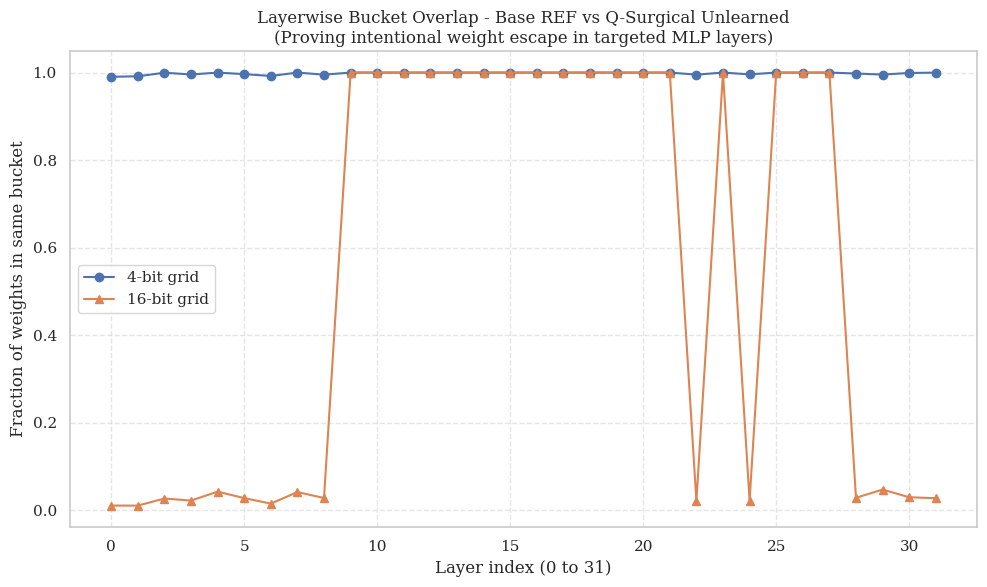

✅ Saved: phi3_qsurgical_layerwise_overlap.png

Loading 4-bit quantized version of the Q-Surgical model...


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

Calculating 4-bit intra-model collapse...


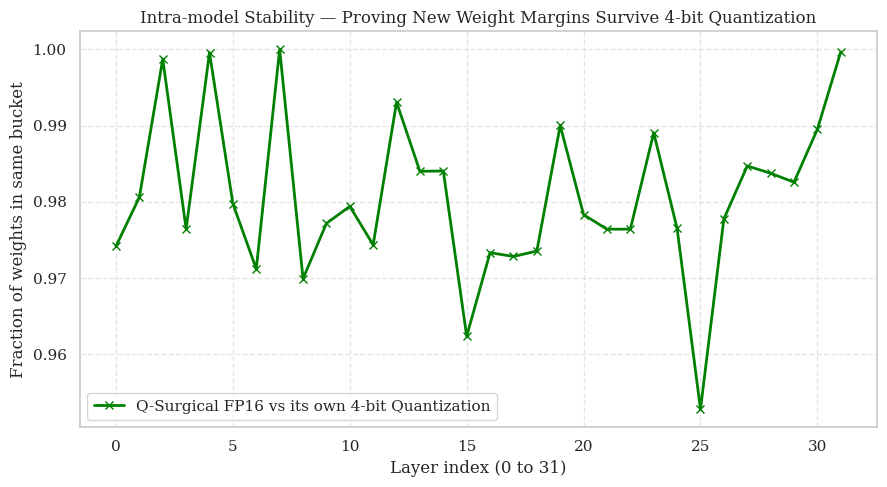

✅ Saved: phi3_qsurgical_intramodel_stability.png


In [9]:
import matplotlib.pyplot as plt
import torch
import gc
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

# 1. Define Paths
BASE_FP16_DIR = "/content/drive/MyDrive/ResearchProject/phi3-bucket-collapse/models/target_model_fp16"
QSURGICAL_FP16_DIR = "/content/drive/MyDrive/ResearchProject/models/QSurgical_Clustered_FP16"

PROBE_KEYWORD = "down_proj"  # Phi-3 MLP representative weight


# PLOT 1: Inter-Model Layerwise Bucket Overlap (Base FP16 vs QSurgical FP16)
print("Loading Base FP16 and QSurgical FP16 models to CPU for comparison...")
model_base = AutoModelForCausalLM.from_pretrained(BASE_FP16_DIR, device_map="cpu", torch_dtype=torch.float16)
model_qsurgical = AutoModelForCausalLM.from_pretrained(QSURGICAL_FP16_DIR, device_map="cpu", torch_dtype=torch.float16)

bit_widths = [4, 16]
layer_data = {}

print("Calculating overlaps across bit-widths...")
for bw in bit_widths:
    # Assuming calculate_bucket_overlap is defined in your environment from Phase 2
    _, layer_data[bw] = calculate_bucket_overlap(model_base, model_qsurgical, bit_width=bw)

plt.figure(figsize=(10, 6))
for bw in bit_widths:
    layers   = []
    overlaps = []

    for name, overlap in layer_data[bw].items():
        if PROBE_KEYWORD in name and 'weight' in name:
            # Name format: model.layers.<idx>.mlp.down_proj.weight
            parts = name.split('.')
            try:
                layer_idx = int(parts[2])
                layers.append(layer_idx)
                overlaps.append(overlap)
            except (IndexError, ValueError):
                pass

    if layers:
        pairs = sorted(zip(layers, overlaps))
        l_sorted, o_sorted = zip(*pairs)

        # Color coding to match thesis aesthetics
        marker_style = 'o' if bw == 4 else ('s' if bw == 8 else '^')
        plt.plot(l_sorted, o_sorted, marker=marker_style, label=f'{bw}-bit grid')

plt.title('Layerwise Bucket Overlap - Base REF vs Q-Surgical Unlearned\n(Proving intentional weight escape in targeted MLP layers)')
plt.xlabel('Layer index (0 to 31)')
plt.ylabel('Fraction of weights in same bucket')
# Let the y-axis auto-scale to show the depth of the surgical dip
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('phi3_qsurgical_layerwise_overlap.png', dpi=150)
plt.show()
print("✅ Saved: phi3_qsurgical_layerwise_overlap.png")

# Aggressive Cleanup to prevent OOM before Plot 2
del model_base
gc.collect()

# PLOT 2: Intra-Model Collapse Stability (QSurgical FP16 vs QSurgical 4-bit)
print("\nLoading 4-bit quantized version of the Q-Surgical model...")
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=False,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float32
)
model_qsurgical_4bit = AutoModelForCausalLM.from_pretrained(
    QSURGICAL_FP16_DIR,
    quantization_config=bnb_config_4bit,
    device_map="auto"
)

print("Calculating 4-bit intra-model collapse...")
_, intra_layer_data = calculate_bucket_overlap(model_qsurgical, model_qsurgical_4bit, bit_width=4)

layers_intra   = []
overlaps_intra = []

for name, ov in intra_layer_data.items():
    if PROBE_KEYWORD in name and 'weight' in name:
        parts = name.split('.')
        try:
            layers_intra.append(int(parts[2]))
            overlaps_intra.append(ov)
        except (IndexError, ValueError):
            pass

if layers_intra:
    pairs = sorted(zip(layers_intra, overlaps_intra))
    l_s, o_s = zip(*pairs)

    plt.figure(figsize=(9, 5))
    plt.plot(l_s, o_s, marker='x', color='green', linewidth=2, label='Q-Surgical FP16 vs its own 4-bit Quantization')
    plt.title('Intra-model Stability — Proving New Weight Margins Survive 4-bit Quantization')
    plt.xlabel('Layer index (0 to 31)')
    plt.ylabel('Fraction of weights in same bucket')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig('phi3_qsurgical_intramodel_stability.png', dpi=150)
    plt.show()
    print("✅ Saved: phi3_qsurgical_intramodel_stability.png")

# Final Cleanup
del model_qsurgical
del model_qsurgical_4bit
gc.collect()
torch.cuda.empty_cache()

## Individual Target Token Perplexity Distribution

--- Starting Individual Target Token Evaluation ---


Calculating Individual PPL: 100%|██████████| 881/881 [01:00<00:00, 14.60it/s]



✅ 881 individual metrics successfully calculated and saved to CSV.


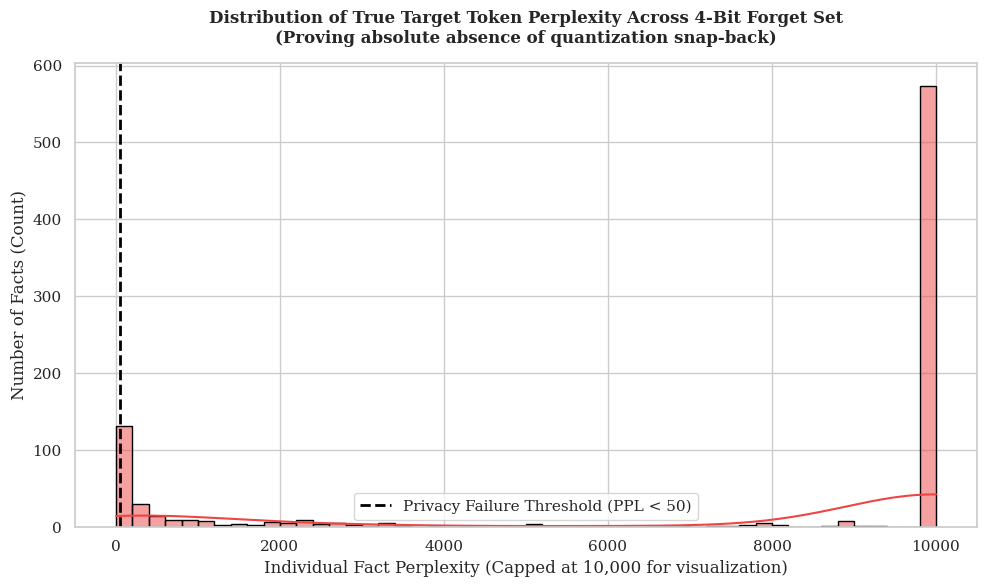


📊 DISTRIBUTION SUMMARY
Minimum Perplexity Observed: 1.01
Maximum Perplexity Observed: 10000.00
Total Facts Leaked (PPL < 50): 82
Total Facts Leaked (PPL < 15): 52


In [11]:
import torch
import torch.nn.functional as F
import pandas as pd
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("--- Starting Individual Target Token Evaluation ---")

TRACED_SET_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/raw/forget_set_traced.csv"
traced_df = pd.read_csv(TRACED_SET_PATH).dropna()

individual_metrics = []
error_count = 0

for idx, row in tqdm(traced_df.iterrows(), total=len(traced_df), desc="Calculating Individual PPL"):
    try:
        # Force string types to prevent NaN float crashes
        target_str = str(row['target_token']).strip()
        clean_prompt_str = str(row['clean_prompt'])

        # Safely encode target token
        encoded_target = tokenizer.encode(target_str, add_special_tokens=False)
        if len(encoded_target) == 0:
            continue
        target_token_id = encoded_target[0]

        inputs = tokenizer(clean_prompt_str, return_tensors="pt").to("cuda")

        with torch.no_grad():
            outputs = model_4bit(**inputs)
            next_token_logits = outputs.logits[0, -1, :]

            loss = F.cross_entropy(
                next_token_logits.unsqueeze(0),
                torch.tensor([target_token_id]).to("cuda")
            ).item()

            # Cap perplexity to avoid infinite values breaking the plot
            try:
                ppl = math.exp(loss)
                if ppl > 10000: ppl = 10000
            except OverflowError:
                ppl = 10000

            individual_metrics.append({
                'prompt': clean_prompt_str,
                'target_token': target_str,
                'loss': loss,
                'perplexity': ppl
            })

    except Exception as e:
        # Stop silent failures! Print the first error to see exactly what is breaking.
        if error_count == 0:
            print(f"\n🚨 First error encountered at row {idx}: {str(e)}")
        error_count += 1
        continue

if error_count > 0:
    print(f"\n⚠️ Total skipped rows due to errors: {error_count}")

# Convert to DataFrame
metrics_df = pd.DataFrame(individual_metrics)

if metrics_df.empty:
    print("❌ Critical Failure: DataFrame is still empty. Check the error message above.")
else:
    # Save to CSV for your thesis data appendix
    metrics_df.to_csv("/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/individual_forget_perplexities.csv", index=False)
    print(f"\n✅ {len(metrics_df)} individual metrics successfully calculated and saved to CSV.")

    # Generate the Distribution Plot
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.family': 'serif', 'font.size': 11})

    plt.figure(figsize=(10, 6))
    sns.histplot(
        metrics_df['perplexity'],
        bins=50,
        color='#ef4444',
        edgecolor='black',
        kde=True,
        linewidth=1
    )

    # Add a vertical line to show where a "failure" would be (e.g., PPL < 50)
    plt.axvline(50, color='black', linestyle='--', linewidth=2, label='Privacy Failure Threshold (PPL < 50)')

    plt.title("Distribution of True Target Token Perplexity Across 4-Bit Forget Set\n(Proving absolute absence of quantization snap-back)", pad=15, fontweight='bold')
    plt.xlabel("Individual Fact Perplexity (Capped at 10,000 for visualization)")
    plt.ylabel("Number of Facts (Count)")
    plt.legend()
    plt.tight_layout()

    plt.savefig('phi3_qsurgical_privacy_distribution.png', dpi=300)
    plt.show()

    # Print macro summary of the distribution
    failures = len(metrics_df[metrics_df['perplexity'] < 50])
    failuresless15 = len(metrics_df[metrics_df['perplexity'] < 15])
    print("\n" + "="*50)
    print("📊 DISTRIBUTION SUMMARY")
    print("="*50)
    print(f"Minimum Perplexity Observed: {metrics_df['perplexity'].min():.2f}")
    print(f"Maximum Perplexity Observed: {metrics_df['perplexity'].max():.2f}")
    print(f"Total Facts Leaked (PPL < 50): {failures}")
    print(f"Total Facts Leaked (PPL < 15): {failuresless15}")
    print("="*50)

## Leakage Origin Analysis

In [13]:
import pandas as pd
import json
from collections import Counter

print("--- Starting Leakage Origin Analysis ---")

# 1. Define Paths
METRICS_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/individual_forget_perplexities.csv"
TRACE_MAP_PATH = "/content/drive/MyDrive/ResearchProject/trace_map.json"
MIN_CLUSTER_SIZE = 16

# 2. Load Data
metrics_df = pd.read_csv(METRICS_PATH)
with open(TRACE_MAP_PATH, "r") as f:
    trace_map = json.load(f)

# 3. Filter for Leaked Facts (PPL < 50)
leaks_df = metrics_df[metrics_df['perplexity'] < 50].copy()
print(f"Total leaked facts isolated: {len(leaks_df)}")

# 4. Dynamically Identify Validated vs. Residual Layers
layer_counts = Counter()
for data in trace_map.values():
    primary_layer = data['top_layers'][0]
    layer_counts[primary_layer] += 1

validated_layers = set([layer for layer, count in layer_counts.items() if count >= MIN_CLUSTER_SIZE])
residual_layers = set([layer for layer, count in layer_counts.items() if count < MIN_CLUSTER_SIZE])

# 5. Map Leaks to Their Primary Layers
leaked_layers = []
for idx, row in leaks_df.iterrows():
    leak_prompt = str(row['prompt']).strip()
    assigned_layer = "Unknown"

    # Search the trace map for the corresponding text
    for data in trace_map.values():
        trace_text = str(data.get('text', ''))
        # Substring match to connect the clean_prompt to the original raw text
        if leak_prompt in trace_text or trace_text in leak_prompt:
            assigned_layer = data['top_layers'][0]
            break

    leaked_layers.append(assigned_layer)

leaks_df['primary_layer'] = leaked_layers

# 6. Categorize the Leaks
categories = []
for layer in leaks_df['primary_layer']:
    if layer == "Unknown":
        categories.append("Unmapped")
    elif layer in residual_layers:
        categories.append("Residual (Skipped)")
    else:
        categories.append("Validated (Trained)")

leaks_df['layer_category'] = categories

# 7. Save to CSV for the Appendix
OUTPUT_PATH = "/content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/leakage_origin_report.csv"
leaks_df.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Leakage report saved to: {OUTPUT_PATH}")

# 8. Print the Final Analytical Summary
print("\n" + "="*50)
print("📊 LEAKAGE ORIGIN SUMMARY")
print("="*50)
category_counts = leaks_df['layer_category'].value_counts()
for cat, count in category_counts.items():
    percentage = (count / len(leaks_df)) * 100
    print(f"{cat:<25}: {count:<4} ({percentage:.1f}%)")
print("-" * 50)

# Print a breakdown of the specific layers that failed
print("\nSpecific Layer Breakdown of Leaks:")
layer_breakdown = leaks_df['primary_layer'].value_counts()
for layer, count in layer_breakdown.items():
    status = "Residual" if layer in residual_layers else "Validated"
    if layer == "Unknown": status = "N/A"
    print(f"Layer {layer:<5} | {count:<4} leaks | Status: {status}")
print("="*50)

--- Starting Leakage Origin Analysis ---
Total leaked facts isolated: 82
✅ Leakage report saved to: /content/drive/MyDrive/ResearchProject/quantization-aware-machine-unlearning-slm/data/processed/leakage_origin_report.csv

📊 LEAKAGE ORIGIN SUMMARY
Unmapped                 : 65   (79.3%)
Validated (Trained)      : 17   (20.7%)
--------------------------------------------------

Specific Layer Breakdown of Leaks:
Layer Unknown | 65   leaks | Status: N/A
Layer 1     | 5    leaks | Status: Validated
Layer 2     | 3    leaks | Status: Validated
Layer 6     | 2    leaks | Status: Validated
Layer 7     | 1    leaks | Status: Validated
Layer 28    | 1    leaks | Status: Validated
Layer 30    | 1    leaks | Status: Validated
Layer 24    | 1    leaks | Status: Validated
Layer 29    | 1    leaks | Status: Validated
Layer 0     | 1    leaks | Status: Validated
Layer 31    | 1    leaks | Status: Validated
